# 🏏 IPL Team Win Prediction



## 1. Install & Import Libraries

In [8]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Data




In [11]:
def generate_synthetic_ipl_data(n_matches=900):
    teams = ['Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bangalore',
             'Kolkata Knight Riders', 'Delhi Capitals', 'Punjab Kings',
             'Rajasthan Royals', 'Sunrisers Hyderabad', 'Gujarat Titans', 'Lucknow Super Giants']
    venues = ['Wankhede Stadium', 'M. A. Chidambaram Stadium', 'Eden Gardens',
              'Arun Jaitley Stadium', 'Narendra Modi Stadium', 'M. Chinnaswamy Stadium']
    # give teams slightly different underlying strengths so the model has real signal to learn
    strength = {t: np.random.uniform(0.35, 0.65) for t in teams}

    rows = []
    for _ in range(n_matches):
        t1, t2 = np.random.choice(teams, 2, replace=False)
        venue = np.random.choice(venues)
        toss_winner = np.random.choice([t1, t2])
        toss_decision = np.random.choice(['bat', 'field'])
        # win probability driven by relative strength + small toss/home advantage
        p1 = strength[t1] / (strength[t1] + strength[t2])
        p1 += 0.03 if toss_winner == t1 else -0.03
        p1 = np.clip(p1, 0.05, 0.95)
        winner = t1 if np.random.rand() < p1 else t2
        rows.append([t1, t2, venue, toss_winner, toss_decision, winner])

    return pd.DataFrame(rows, columns=['team1', 'team2', 'venue', 'toss_winner', 'toss_decision', 'winner'])


df = None
try:
    from google.colab import files
    print('Upload matches.csv (or press Cancel/skip to use synthetic sample data instead)...')
    uploaded = files.upload()
    if uploaded:
        fname = list(uploaded.keys())[0]
        df = pd.read_csv(fname)
        print(f'Loaded uploaded file: {fname}')
except Exception as e:
    print('Skipping upload (not on Colab or upload cancelled).')

if df is None:
    df = generate_synthetic_ipl_data()
    print('Using synthetic sample data (replace with a real Kaggle IPL dataset for real predictions).')

print(df.shape)
df.head()

Upload matches.csv (or press Cancel/skip to use synthetic sample data instead)...


Saving IPL_Team_Prediction.ipynb to IPL_Team_Prediction (1).ipynb
Skipping upload (not on Colab or upload cancelled).
Using synthetic sample data (replace with a real Kaggle IPL dataset for real predictions).
(900, 6)


,team1,team2,venue,toss_winner,toss_decision,winner
0,Gujarat Titans,Royal Challengers Bangalore,Arun Jaitley Stadium,Royal Challengers Bangalore,field,Gujarat Titans
1,Lucknow Super Giants,Punjab Kings,M. Chinnaswamy Stadium,Lucknow Super Giants,field,Lucknow Super Giants
2,Chennai Super Kings,Lucknow Super Giants,Wankhede Stadium,Chennai Super Kings,field,Lucknow Super Giants
3,Mumbai Indians,Punjab Kings,Arun Jaitley Stadium,Mumbai Indians,field,Mumbai Indians
4,Royal Challengers Bangalore,Lucknow Super Giants,M. A. Chidambaram Stadium,Lucknow Super Giants,field,Lucknow Super Giants


## 3. Clean & Standardize Columns




In [3]:
col_map = {
    'Team1': 'team1', 'team_1': 'team1',
    'Team2': 'team2', 'team_2': 'team2',
    'Venue': 'venue', 'city': 'venue',
    'TossWinner': 'toss_winner', 'toss winner': 'toss_winner',
    'TossDecision': 'toss_decision', 'toss_decision ': 'toss_decision',
    'WinningTeam': 'winner', 'match_winner': 'winner', 'Winner': 'winner'
}
df = df.rename(columns=col_map)

required_cols = ['team1', 'team2', 'venue', 'toss_winner', 'toss_decision', 'winner']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    print(f'⚠️ Missing expected columns: {missing}')
    print('Available columns:', list(df.columns))
    print('Update col_map above to match your dataset, or keep using the synthetic data.')
else:
    df = df.dropna(subset=required_cols).reset_index(drop=True)
    print('Data cleaned ✅')
    print(df.shape)
df.head()

Data cleaned ✅
(900, 6)


,team1,team2,venue,toss_winner,toss_decision,winner
0,Gujarat Titans,Royal Challengers Bangalore,Arun Jaitley Stadium,Royal Challengers Bangalore,field,Gujarat Titans
1,Lucknow Super Giants,Punjab Kings,M. Chinnaswamy Stadium,Lucknow Super Giants,field,Lucknow Super Giants
2,Chennai Super Kings,Lucknow Super Giants,Wankhede Stadium,Chennai Super Kings,field,Lucknow Super Giants
3,Mumbai Indians,Punjab Kings,Arun Jaitley Stadium,Mumbai Indians,field,Mumbai Indians
4,Royal Challengers Bangalore,Lucknow Super Giants,M. A. Chidambaram Stadium,Lucknow Super Giants,field,Lucknow Super Giants


## 4. Feature Engineering

In [4]:
def compute_head_to_head(df):
    """Historical win rate of team1 over team2 (as of that point in the dataset)."""
    h2h_wins = {}
    h2h_total = {}
    ratios = []
    for _, row in df.iterrows():
        t1, t2, winner = row['team1'], row['team2'], row['winner']
        key = tuple(sorted([t1, t2]))
        total = h2h_total.get(key, 0)
        wins_t1 = h2h_wins.get((key, t1), 0)
        ratio = wins_t1 / total if total > 0 else 0.5
        ratios.append(ratio)
        h2h_total[key] = total + 1
        h2h_wins[(key, winner)] = h2h_wins.get((key, winner), 0) + 1
    return ratios

def compute_recent_form(df, window=5):
    """Rolling win rate of team1 over its last `window` matches."""
    history = {}
    form = []
    for _, row in df.iterrows():
        t1, winner = row['team1'], row['winner']
        past = history.get(t1, [])
        recent = past[-window:]
        form.append(sum(recent) / len(recent) if recent else 0.5)
        history.setdefault(t1, []).append(1 if winner == t1 else 0)
    return form

df['h2h_team1_winrate'] = compute_head_to_head(df)
df['team1_recent_form'] = compute_recent_form(df)
df['toss_winner_is_team1'] = (df['toss_winner'] == df['team1']).astype(int)
df['target'] = (df['winner'] == df['team1']).astype(int)  # 1 = team1 wins, 0 = team2 wins

encoders = {}
for col in ['team1', 'team2', 'venue', 'toss_decision']:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    encoders[col] = le

feature_cols = ['team1_enc', 'team2_enc', 'venue_enc', 'toss_decision_enc',
                 'toss_winner_is_team1', 'h2h_team1_winrate', 'team1_recent_form']

X = df[feature_cols]
y = df['target']
print('Features ready ✅')
X.head()

Features ready ✅


,team1_enc,team2_enc,venue_enc,toss_decision_enc,toss_winner_is_team1,h2h_team1_winrate,team1_recent_form
0,2,8,0,1,0,0.5,0.5
1,4,6,3,1,1,0.5,0.5
2,0,4,5,1,1,0.5,0.5
3,5,6,0,1,1,0.5,0.5
4,8,4,2,1,0,0.5,0.5


## 5. Train / Test Split & Model Training

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f'{name}: accuracy = {acc:.3f}')

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f'\nBest model: {best_model_name} ({results[best_model_name]:.3f} accuracy)')

Logistic Regression: accuracy = 0.528
Random Forest: accuracy = 0.533

Best model: Random Forest (0.533 accuracy)


## 6. Evaluation

              precision    recall  f1-score   support

  team2 wins       0.51      0.35      0.42        85
  team1 wins       0.55      0.69      0.61        95

    accuracy                           0.53       180
   macro avg       0.53      0.52      0.51       180
weighted avg       0.53      0.53      0.52       180



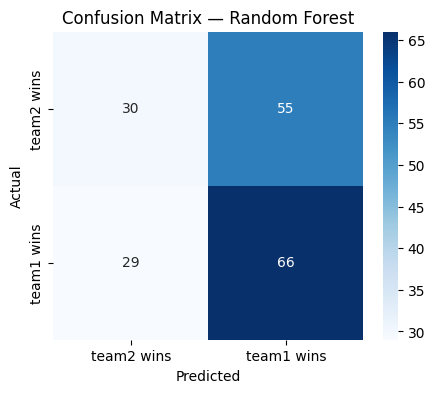

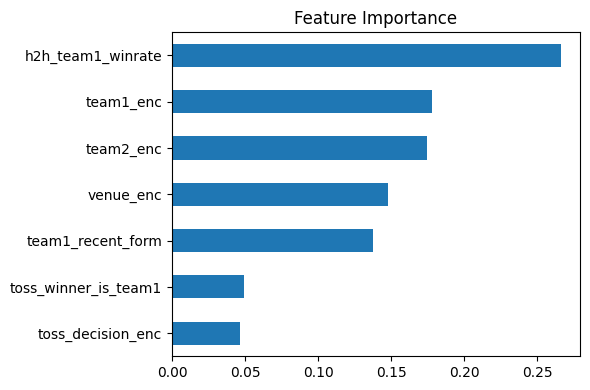

In [13]:
preds = best_model.predict(X_test)
print(classification_report(y_test, preds, target_names=['team2 wins', 'team1 wins']))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['team2 wins', 'team1 wins'],
            yticklabels=['team2 wins', 'team1 wins'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
    importances.plot(kind='barh', figsize=(6, 4), title='Feature Importance')
    plt.tight_layout()
    plt.show()

## 7. Predict a Custom Match-Up

Change `team_a`, `team_b`, `venue_name`, `toss_winner_name`, and `toss_decision_name` below and re-run the cell.

In [14]:
def predict_winner(team_a, team_b, venue_name, toss_winner_name, toss_decision_name):
    def safe_encode(le, value, col_name):
        if value not in le.classes_:
            print(f"⚠️ '{value}' not seen in training data for {col_name}; using nearest fallback.")
            return 0
        return le.transform([value])[0]

    h2h_key = tuple(sorted([team_a, team_b]))
    sub = df[(df['team1'].isin([team_a, team_b])) & (df['team2'].isin([team_a, team_b]))]
    h2h_rate = (sub['winner'] == team_a).mean() if len(sub) > 0 else 0.5

    team_a_matches = df[df['team1'] == team_a]
    recent_form = (team_a_matches['winner'] == team_a).tail(5).mean() if len(team_a_matches) > 0 else 0.5

    row = pd.DataFrame([{
        'team1_enc': safe_encode(encoders['team1'], team_a, 'team1'),
        'team2_enc': safe_encode(encoders['team2'], team_b, 'team2'),
        'venue_enc': safe_encode(encoders['venue'], venue_name, 'venue'),
        'toss_decision_enc': safe_encode(encoders['toss_decision'], toss_decision_name, 'toss_decision'),
        'toss_winner_is_team1': 1 if toss_winner_name == team_a else 0,
        'h2h_team1_winrate': h2h_rate if not np.isnan(h2h_rate) else 0.5,
        'team1_recent_form': recent_form if not np.isnan(recent_form) else 0.5,
    }])[feature_cols]

    prob_a = best_model.predict_proba(row)[0][1]
    winner = team_a if prob_a >= 0.5 else team_b
    print(f'{team_a} win probability: {prob_a:.1%}')
    print(f'{team_b} win probability: {1 - prob_a:.1%}')
    print(f'\n🏆 Predicted winner: {winner}')
    return winner

# --- Edit these and re-run ---
team_a = df['team1'].iloc[0]
team_b = df['team2'].iloc[0]
venue_name = df['venue'].iloc[0]
toss_winner_name = team_a
toss_decision_name = 'bat'

predict_winner(team_a, team_b, venue_name, toss_winner_name, toss_decision_name)

Gujarat Titans win probability: 60.3%
Royal Challengers Bangalore win probability: 39.7%

🏆 Predicted winner: Gujarat Titans


np.str_('Gujarat Titans')